In [2]:
# Cell 1: Imports & Parameter
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

from utils.parquet_io import load_parquet
# >>> Pfad zu DEINEM Run anpassen:
run_dir = Path(r"C:\Dev\Bachelorarbeit\data\accounting\runs\cpcv_final\log_ppo_S0_final\ppo_log_state0_cpcv_20251216_055319\E2")
paths = [f"Path_{i:02d}" for i in range(1, 6)]

def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df


In [15]:
df_btc = load_and_info(run_dir / "Path_01/rewards.parquet")
display(df_btc.head(), df_btc.tail())


--- rewards.parquet ---
Shape: (1505, 15)
Columns: 15


,round,t,nav_t,nav_t-1,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
0,1,2015-01-05 00:00:00+00:00,1.000001e+06,1.000000e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1,2,2015-01-06 00:00:00+00:00,1.000002e+06,1.000001e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
2,3,2015-01-07 00:00:00+00:00,1.000003e+06,1.000002e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
3,4,2015-01-08 00:00:00+00:00,1.000003e+06,1.000003e+06,8.333330e-07,0.0,0.0,8.333330e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1
4,5,2015-01-09 00:00:00+00:00,1.000004e+06,1.000003e+06,5.555554e-07,0.0,0.0,5.555554e-07,log,ex_ante,0.05,1.0,1.0,rolling,0.1


,round,t,nav_t,nav_t-1,r_log_t,icvar_t,delta_mdd_t,reward_t,reward_kind,icvar_mode,alpha,lambda_,gamma,estimator,ewm_alpha
1500,1506,2020-12-24 00:00:00+00:00,1.988716e+06,1.955562e+06,0.016812,0.0,0.0,0.016812,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1501,1507,2020-12-28 00:00:00+00:00,2.149816e+06,1.988716e+06,0.077893,0.0,0.0,0.077893,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1502,1508,2020-12-29 00:00:00+00:00,2.159724e+06,2.149816e+06,0.004598,0.0,0.0,0.004598,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1503,1509,2020-12-30 00:00:00+00:00,2.204472e+06,2.159724e+06,0.020508,0.0,0.0,0.020508,log,ex_ante,0.05,1.0,1.0,rolling,0.1
1504,1510,2020-12-31 00:00:00+00:00,2.193689e+06,2.204472e+06,-0.004903,0.0,0.0,-0.004903,log,ex_ante,0.05,1.0,1.0,rolling,0.1


In [16]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


Path_01
Path_02
Path_03
Path_04
Path_05


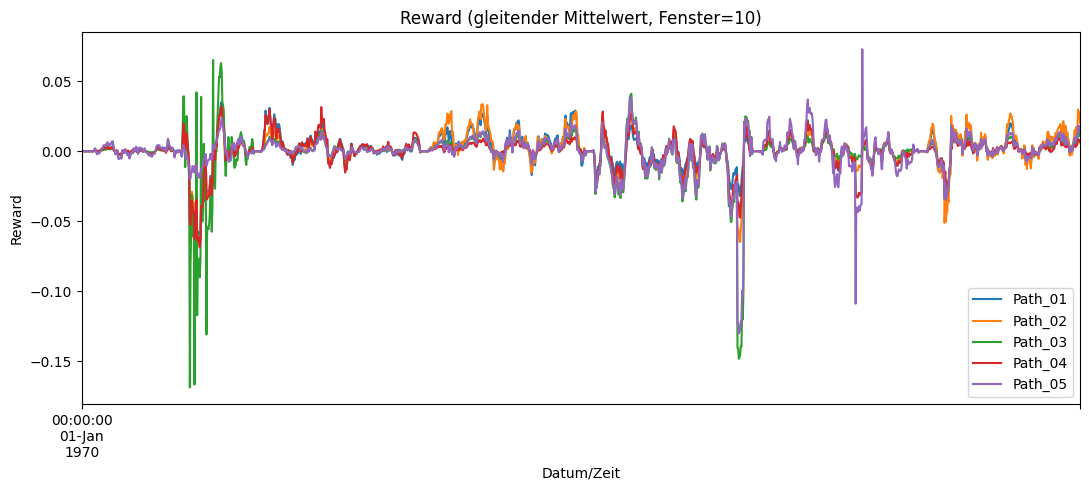

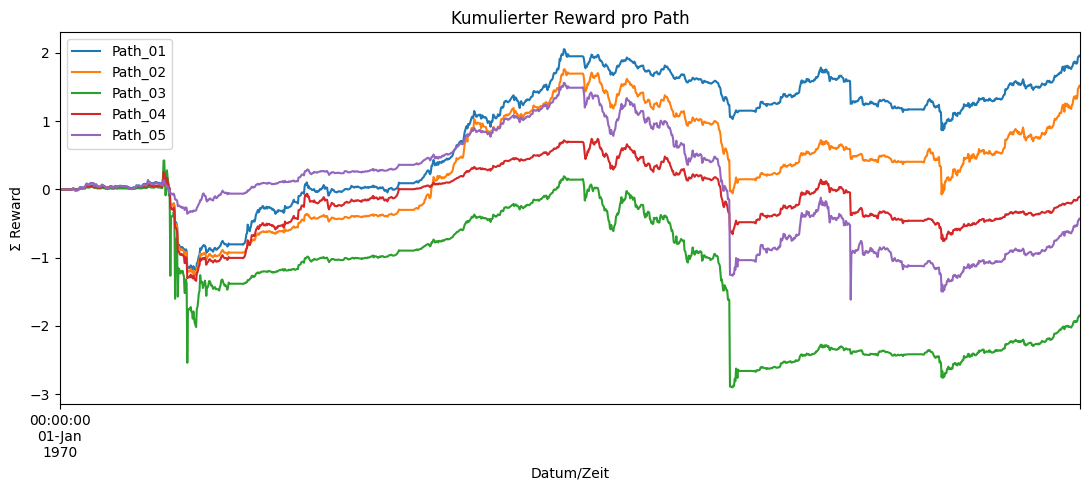

In [17]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("Reward (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Reward")
plt.tight_layout(); plt.show()

# Kumuliert:
wide_cum = wide.fillna(0).cumsum()
ax = wide_cum.plot(figsize=(11,5))
ax.set_title("Kumulierter Reward pro Path")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("Σ Reward")
plt.tight_layout(); plt.show()


In [18]:
# Cell 2: Laden und auf breites Format bringen (eine Spalte je Path)
wide = None

for pid in paths:

    p = run_dir / pid
    f_rewards = p / "rewards.parquet"
    f_snap    = p / "portfolio_snapshots.parquet"

    if f_rewards.is_file():
        df = load_parquet(f_rewards)
    elif f_snap.is_file():
        df = load_parquet(f_snap)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["nav_t"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")

if wide is None:
    raise SystemExit("Keine Daten geladen.")

wide = wide.sort_index()


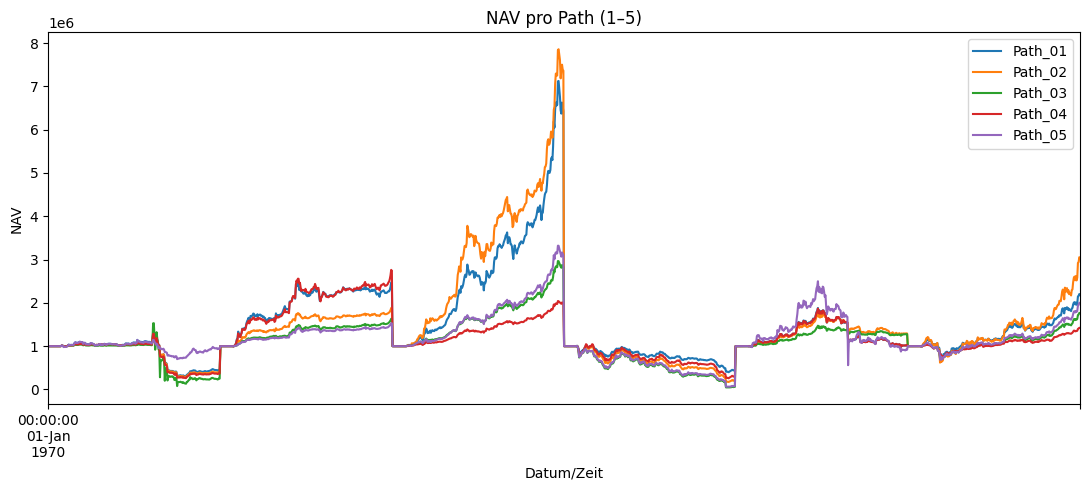

In [19]:
# Cell 3: Plot – Reward pro Path (roh)
ax = wide.plot(figsize=(11,5))
ax.set_title("NAV pro Path (1–5)")
ax.set_xlabel("Datum/Zeit")
ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()

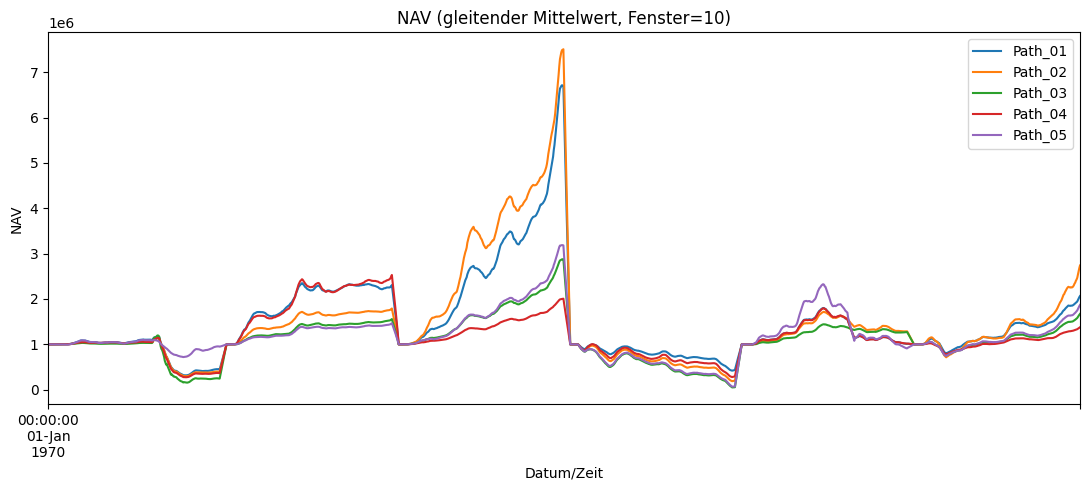

In [20]:
# (Optional) Glättung und/oder kumulierter Reward zum besseren Vergleich
# Glätten:
wide_smooth = wide.rolling(10, min_periods=1).mean()
ax = wide_smooth.plot(figsize=(11,5))
ax.set_title("NAV (gleitender Mittelwert, Fenster=10)")
ax.set_xlabel("Datum/Zeit"); ax.set_ylabel("NAV")
plt.tight_layout(); plt.show()


In [3]:
wide = None

for pid in paths:
    print(pid)
    p = run_dir / pid
    f_trade   = p / "trade_events.parquet"


    if f_trade.is_file():
        df = load_parquet(f_trade)
    else:
        print(f"⚠️ Keine rewards/portfolio_snapshots in {pid}")
        continue

    # Datum/Zeit holen
    if "date" in df.columns:
        idx = pd.to_datetime(df["date"], utc=True, errors="coerce")
    elif "timestamp" in df.columns:
        idx = pd.to_datetime(df["timestamp"], unit="s", utc=True, errors="coerce")
    else:
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")

    # Reward-Spalte finden
    reward_col = next((c for c in ["reward_t","rewards","rwd","step_reward"] if c in df.columns), None)
    if reward_col is None:
        print(f"⚠️ Keine Reward-Spalte in {pid}")
        continue

    s = pd.Series(df[reward_col].values, index=idx, name=pid).sort_index()
    s = s[~s.index.duplicated(keep="last")]  # doppelte Timestamps entfernen

    wide = s.to_frame() if wide is None else wide.join(s, how="outer")


df_btc = load_and_info(f_trade)
display(df_btc)

Path_01
⚠️ Keine Reward-Spalte in Path_01
Path_02
⚠️ Keine Reward-Spalte in Path_02
Path_03
⚠️ Keine Reward-Spalte in Path_03
Path_04
⚠️ Keine Reward-Spalte in Path_04
Path_05
⚠️ Keine Reward-Spalte in Path_05

--- trade_events.parquet ---
Shape: (151, 11)
Columns: 11


,asset,q,adj_open,p_exec,notional_abs,spread_cost,fees,vol_slip,total_cost,round,t
0,BTC-USD,544.434927,218.039993,218.367053,118886.650626,178.062883,297.216627,0.0,297.216627,20,2015-02-02 00:00:00+00:00
1,SPY,94.000000,169.386810,170.520324,16028.910419,106.550250,40.072276,0.0,40.072276,21,2015-02-03 00:00:00+00:00
2,BTC-USD,486.669374,238.380005,238.737575,116186.266229,174.018373,290.465666,0.0,290.465666,22,2015-02-04 00:00:00+00:00
3,BTC-USD,-186.740517,279.000092,278.581591,52022.470539,78.150933,130.056176,0.0,130.056176,46,2015-03-11 00:00:00+00:00
4,IEMG,-289.000000,36.492794,36.334400,10500.641659,45.775818,26.251604,0.0,26.251604,60,2015-03-31 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
146,BTC-USD,-3.647261,15588.540039,15565.157229,56770.194023,85.283217,141.925485,0.0,141.925485,1473,2020-11-06 00:00:00+00:00
147,IAU,484.000000,35.820000,35.904696,17377.872892,40.993040,43.444682,0.0,43.444682,1481,2020-11-18 00:00:00+00:00
148,BTC-USD,-1.445636,19690.216797,19660.681471,28422.187639,42.697328,71.055469,0.0,71.055469,1489,2020-12-01 00:00:00+00:00
149,EWJ,414.000000,59.969372,60.051926,24861.497201,34.177277,62.153743,0.0,62.153743,1503,2020-12-21 00:00:00+00:00
